# Traffic sign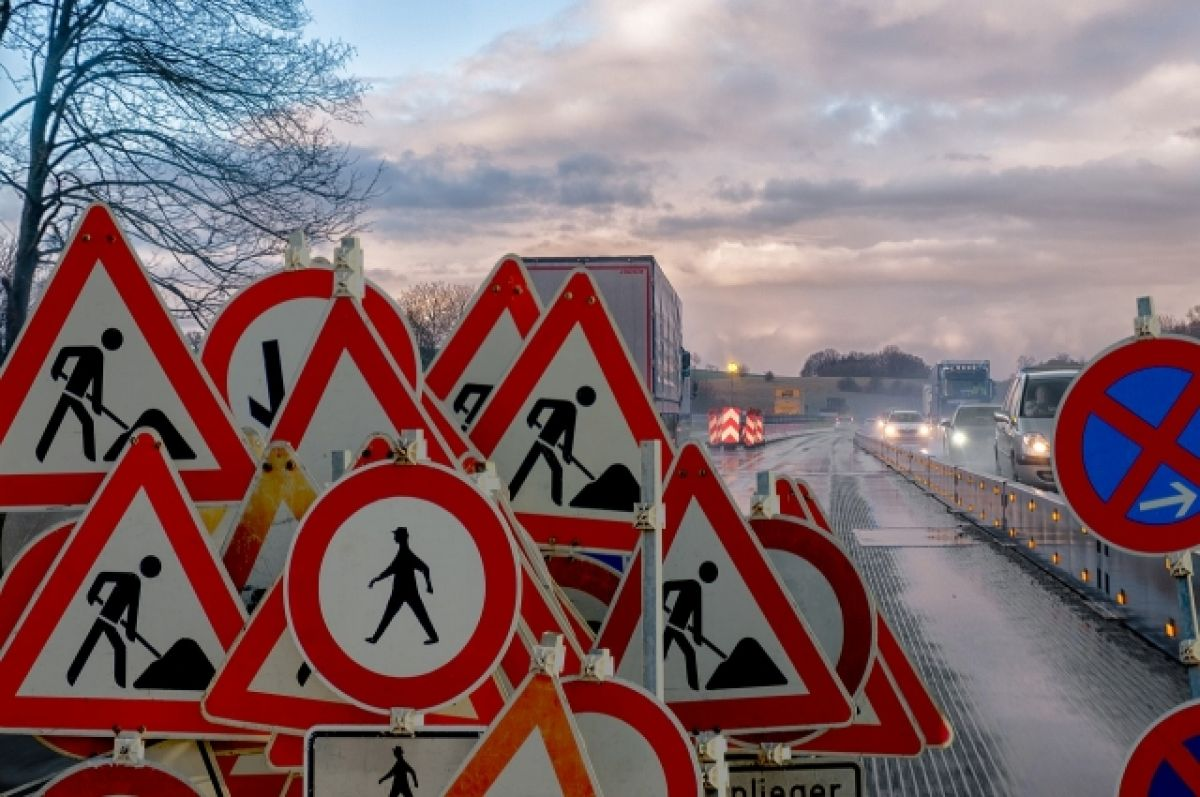

## Classification task



Traffic sign recognition is a tough real-world problem with high industrial value. Even though commercial systems exist, there aren't many unbiased comparisons of different approaches, and comprehensive datasets are rarely free.

This is a multi-class classification task with heavily imbalanced data. Signs differ a lot in color, shape, and text/icons, but some sub-classes (like speed limits) look almost identical. The classifier has to deal with massive variations in appearance caused by lighting shifts, partial occlusions, rotations, weather, and scaling.

While humans can recognize these signs with near-100% accuracy even from single cropped images, it's a real challenge for computer vision. This dataset is a large, realistic benchmark containing over 50,000 images across 43 classes.

The dataset was created from about 10 hours of video recorded while driving on different types of roads in Germany during daytime. The sequences were captured in March, October, and November 2010. A Prosilica GC 1380CH camera with auto-exposure and a frame rate of 25 frames per second was used for data collection. The camera images have a resolution of 1360×1024 pixels. The video sequences are stored in raw Bayer pattern format, but the extracted traffic sign images are converted to RGB color images. Data collection and manual annotation were performed using the NISYS Advanced Development and Analysis Framework1.

We will use the term "traffic sign instance" to refer to a physical real-world traffic sign, in order to distinguish the traffic sign images from those obtained when a car drives past the sign. The sequence of images obtained from a single traffic sign instance will be called a track. Each instance is unique. In other words, the dataset contains only one track for each physical traffic sign.

The GTSRB dataset was compiled from roughly 133,000 labeled traffic sign images, containing 2,416 traffic sign instances across 70 classes, based on the following criteria:

1. Discard tracks with fewer than 30 images.
2. Discard classes with fewer than 9 tracks.
3. For the remaining tracks: if a track contains more than 30 images, perform an equidistant sampling of exactly 30 images.

Step 3 was performed for two reasons. First, the number of traffic sign images in a track varied greatly because it heavily depended on the speed at which the car passed the sign.

Since consecutive images of a slow-moving traffic sign look almost identical, these images do not contribute to the diversity of the dataset. On the contrary, this causes an undesirable imbalance of dependent images. Second, despite the first point, the appearance of a traffic sign changes over time. Faraway traffic sign images result in low resolution, while close ones are prone to motion blur. Lighting can change, and the movement of the car affects the perspective relative to occlusion. Choosing a fixed number of images for each traffic sign increases the diversity of the dataset and also avoids imbalance caused by a large variation in the number of nearly identical images.

The selection procedure described above reduced the number of images to approximately 50,000 images across 43 classes.

https://www.ini.rub.de/upload/file/1470692848_f03494010c16c36bab9e/StallkampEtAl_GTSRB_IJCNN2011.pdf

### Classes

| №  | Class NAme                                   |
| -- | -------------------------------------------------- |
| 0  | Speed limit (20 km/h)                              |
| 1  | Speed limit (30 km/h)                              |
| 2  | Speed limit (50 km/h)                              |
| 3  | Speed limit (60 km/h)                              |
| 4  | Speed limit (70 km/h)                              |
| 5  | Speed limit (80 km/h)                              |
| 6  | End of speed limit (80 km/h)                       |
| 7  | Speed limit (100 km/h)                             |
| 8  | Speed limit (120 km/h)                             |
| 9  | No passing                                         |
| 10 | No passing for vehicles over 3.5 metric tons       |
| 11 | Right-of-way at the next intersection              |
| 12 | Priority road                                      |
| 13 | Yield                                              |
| 14 | Stop                                               |
| 15 | No vehicles                                        |
| 16 | Vehicles over 3.5 metric tons prohibited           |
| 17 | No entry                                           |
| 18 | General caution                                    |
| 19 | Dangerous curve to the left                        |
| 20 | Dangerous curve to the right                       |
| 21 | Double curve                                       |
| 22 | Bumpy road                                         |
| 23 | Slippery road                                      |
| 24 | Road narrows on the right                          |
| 25 | Road work                                          |
| 26 | Traffic signals                                    |
| 27 | Pedestrians                                        |
| 28 | Children crossing                                  |
| 29 | Bicycles crossing                                  |
| 30 | Beware of ice/snow                                 |
| 31 | Wild animals crossing                              |
| 32 | End of all speed and passing limits                |
| 33 | Turn right ahead                                   |
| 34 | Turn left ahead                                    |
| 35 | Ahead only                                         |
| 36 | Go straight or right                               |
| 37 | Go straight or left                                |
| 38 | Keep right                                         |
| 39 | Keep left                                          |
| 40 | Roundabout mandatory                               |
| 41 | End of no passing                                  |
| 42 | End of no passing by vehicles over 3.5 metric tons |

## Hypotheses

1. Image brightness affects model accuracy
2. Image size will improve the model
3. Normalization will help the neurons

## Project objective

1. Analyze the images
2. Train a baseline DL model
3. Preprocess the data and test CNN architectures
4. Determine the best model


## Work Process

1. Dataset splitting
2. Image dataset analysis
3. Image preprocessing
4. Model training
5. Model improvement

# Step 1. Import libraries

In [52]:
import os                      # working with the file system
import random                  # random number generation
import pickle                  # data saving / loading (pkl)
import numpy as np             # working with arrays
import pandas as pd            # tables (DataFrame)
from collections import Counter # counting class frequencies
import cv2                     # image processing (OpenCV)
import seaborn as sns          # beautiful plots
import matplotlib.pyplot as plt # plots and visualization

from sklearn.utils import shuffle  # data shuffling
from sklearn.model_selection import train_test_split  # train/test splitting
from sklearn.metrics import (   # model quality metrics
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import tensorflow as tf             # deep learning framework
from tensorflow.keras.models import Sequential, load_model  # sequential model
from tensorflow.keras.layers import (
    Input,                # model input
    Conv2D,               # convolutional layer
    MaxPooling2D,         # max pooling
    AveragePooling2D,     # average pooling
    BatchNormalization,   # batch normalization
    Dropout,              # neuron deactivation (regularization)
    Flatten,              # flattening a tensor into a vector
    Dense                 # fully connected layer
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # image augmentation
from tensorflow.keras.optimizers import Adam                         # Adam optimizer
from tensorflow.keras.callbacks import (
    EarlyStopping,        # stop training when a monitored metric has stopped improving
    ReduceLROnPlateau,    # reduce learning rate
    ModelCheckpoint,      # saving the best model
    TensorBoard           # logging for TensorBoard
)

Below are helper functions to inspect dataset structure, visualize class distributions, and identify image quality issues.

**Inspection:** `inspect_structure()` and `basic_stats()` to check array shapes, data types, pixel values, and channel means.  
**Visualization:** `class_distribution()` to plot class counts, and `show_images()` / `compare_same_class()` to view samples side by side.  
**Quality Filters:** `is_overexposed()`, `is_underexposed()`, and `is_blurry()` to flag problematic images using grayscale histograms and Laplacian variance.  
**Processing:** `enhance()` (applying CLAHE in YUV space) and `denoise()` (using median blur) to clean up the data before training.

In [2]:
# Functions
# Data structure
def inspect_structure(data_dict, name):
    print(f"\n- {name.upper()} -")
    for key, value in data_dict.items():
        if isinstance(value, np.ndarray):
            print(f"{key}: {value.shape} (dtype: {value.dtype})")
        else:
            print(f"{key}: {type(value)} (len: {len(value) if hasattr(value, '__len__') else 'N/A'})")

# Statistics
def basic_stats(data_dict, name):
    features = data_dict['features']
    labels = data_dict['labels']

    print(f"\n- BASIC STATISTICS {name.upper()} -")
    print(f"Sample count: {len(features)}")
    print(f"Unique classes: {len(np.unique(labels))}")
    print(f"Label range: {labels.min()}–{labels.max()}")

    if len(features.shape) == 4:
        h, w, c = features.shape[1:]
        print(f"Image size: {h}x{w}x{c} (channels: RGB)")

    mean_per_channel = np.mean(features, axis=(0, 1, 2))
    print(f"Channel means (R,G,B): {mean_per_channel}")

    flat_pixels = features.reshape(-1, features.shape[-1])
    print(f"Pixel range: {flat_pixels.min():.2f}–{flat_pixels.max():.2f}")
    print(f"Mean/Std across all: {flat_pixels.mean():.2f} / {flat_pixels.std():.2f}")

# Distribution
def class_distribution(data_dict, name):
  labels = data_dict['labels']
  class_counts = Counter(labels)
  df_counts = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count']).sort_index()

  plt.figure(figsize=(12, 6))
  sns.barplot(data=df_counts.reset_index(), x='index', y='count')
  plt.title(f'Class Distribution in {name}')
  plt.xlabel('Class ID')
  plt.ylabel('Sample Count')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

  print(f"Top 5 most frequent: {df_counts.nlargest(5, 'count')}")
  print(f"Top 5 rarest: {df_counts.nsmallest(5, 'count')}")

# Duplicates, brightness, and blanks
def check_issues(data_dict, name):
    features = data_dict['features']
    labels = data_dict['labels']

    print(f"\n CHECKING ISSUES FOR {name.upper()} ")

    hashes = [hash(tuple(img.flatten())) for img in features[:1000]]
    dup_count = len(hashes) - len(set(hashes))
    print(f"Duplicates in sample 1000: {dup_count}")

    zero_imgs = np.sum(np.all(features == 0, axis=(1,2,3)))
    print(f"Blank images: {zero_imgs}")

    brightness = np.mean(features, axis=(1,2,3))
    print(f"Brightness: min={brightness.min():.2f}, max={brightness.max():.2f}, std={brightness.std():.2f}")

# Group filtering for poor quality images
def is_overexposed(img, threshold=190):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return np.mean(gray) > threshold

def is_underexposed(img, threshold=50):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return np.mean(gray) < threshold

def is_blurry(img, threshold=150):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var() < threshold

# Image display
def show_images(X, idx_list, title, n=12):
    plt.figure(figsize=(12, 4))
    plt.suptitle(title, fontsize=16)

    for i, idx in enumerate(idx_list[:n]):
        plt.subplot(2, 6, i+1)
        plt.imshow(X[idx])
        plt.axis("off")
        plt.title(f"idx={idx}")

    plt.show()

# Custom selection to compare same-class image quality
def compare_same_class(class_label, X, y, idx_bad_list, n=1):
    normal_idx = [i for i in range(len(X)) if y[i] == class_label and i not in idx_bad_list]
    bad_idx = [i for i in idx_bad_list if y[i] == class_label]

    plt.figure(figsize=(6*n, 3))

    for i in range(min(n, len(bad_idx), len(normal_idx))):
        plt.subplot(2, n, i+1)
        plt.imshow(X[normal_idx[i]])
        plt.title("Normal")
        plt.axis("off")

        plt.subplot(2, n, n+i+1)
        plt.imshow(X[bad_idx[i]])
        plt.title("Bad")
        plt.axis("off")

    plt.show()

# Training results
def evaluate_multiclass_model(model, X_train, y_train, X_test, y_test):

    y_train_proba = model.predict(X_train, verbose=0)
    y_test_proba = model.predict(X_test, verbose=0)

    y_train_pred = np.argmax(y_train_proba, axis=1)
    y_test_pred = np.argmax(y_test_proba, axis=1)

    if len(y_train.shape) > 1 and y_train.shape[1] > 1:
        y_train_true = np.argmax(y_train, axis=1)
    else:
        y_train_true = y_train

    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test_true = np.argmax(y_test, axis=1)
    else:
        y_test_true = y_test

    results = {
        "train_accuracy": accuracy_score(y_train_true, y_train_pred),
        "test_accuracy": accuracy_score(y_test_true, y_test_pred),

        "train_f1_macro": f1_score(y_train_true, y_train_pred, average='macro'),
        "test_f1_macro": f1_score(y_test_true, y_test_pred, average='macro'),

        "train_recall_macro": recall_score(y_train_true, y_train_pred, average='macro'),
        "test_recall_macro": recall_score(y_test_true, y_test_pred, average='macro'),

        "train_precision_macro": precision_score(y_train_true, y_train_pred, average='macro'),
        "test_precision_macro": precision_score(y_test_true, y_test_pred, average='macro'),
    }

    return results

def enhance(img): # added to normalize brightness, contrast + scale the image
    if img.dtype != np.uint8:
        img_uint8 = np.clip(img, 0, 1) if img.max() <= 1.0 else np.clip(img/255.0, 0, 1)
        img_uint8 = (img_uint8 * 255).astype(np.uint8)
    else:
        img_uint8 = img

    yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)
    yuv[:, :, 0] = clahe.apply(yuv[:, :, 0])
    rgb = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)
    return rgb.astype(np.float32) / 255.0

def denoise(img):  # noise removal
    img_uint8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    den = cv2.medianBlur(img_uint8, 3)
    return den.astype(np.float32) / 255.0

# Final results
def plot_results(results):
  df = pd.DataFrame(results).T

  metrics = ["Accuracy", "Precision", "Recall", "F1"]

  for metric in metrics:
      plt.figure(figsize=(12, 5))

      train_col = f"{metric}_train"
      test_col = f"{metric}_test"

      pivot = df[[train_col, test_col]].copy()
      pivot.columns = ["train", "test"]

      pivot["overfit"] = (pivot["train"] - pivot["test"]) / pivot["train"] * 100

      pivot = pivot.sort_values("test", ascending=False)

      y = np.arange(len(pivot))
      h = 0.35

      plt.barh(y - h/2, pivot["train"], h, label="Train", color="orange")
      plt.barh(y + h/2, pivot["test"], h, label="Test", color="steelblue")

      for i, model in enumerate(pivot.index):
          tr = pivot.loc[model, "train"]
          ts = pivot.loc[model, "test"]
          of = pivot.loc[model, "overfit"]

          plt.text(tr + 1, i - h/2, f"{tr:.1f}%", color="darkred", va="center")
          plt.text(ts + 1, i + h/2, f"{ts:.1f}%", color="darkblue", va="center")
          plt.text(max(tr, ts) + 3, i, f"{of:.1f}%", color="black", va="center")

      plt.yticks(y, pivot.index)
      plt.title(f"{metric} — Train / Test / Overfit%")
      plt.xlabel("Percent (%)")
      plt.grid(axis="x", linestyle="--", alpha=0.4)
      plt.legend()
      plt.tight_layout()
      plt.show()

# Step 2. Import Dataset

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
%cd "./drive/MyDrive/Colab Notebooks/"

/content/drive/MyDrive/Colab Notebooks


In [5]:
with open("./traffic-signs-data/train.p", mode='rb') as training_data:
  train = pickle.load(training_data)

with open("./traffic-signs-data/valid.p", mode='rb') as validation_data:
  valid = pickle.load(validation_data)

with open("./traffic-signs-data/test.p", mode='rb') as testing_data:
  test = pickle.load(testing_data)

In [6]:
X_train, y_train = train['features'], train['labels']
X_validation, y_validation = valid['features'], valid['labels']
X_test, y_test = test['features'], test['labels']

# Step 3. Data analysis

In [7]:
inspect_structure(train, 'Train')
inspect_structure(valid, 'Valid')
inspect_structure(test, 'Test')


- TRAIN -
coords: (34799, 4) (dtype: uint8)
labels: (34799,) (dtype: uint8)
features: (34799, 32, 32, 3) (dtype: uint8)
sizes: (34799, 2) (dtype: uint8)

- VALID -
coords: (4410, 4) (dtype: uint8)
labels: (4410,) (dtype: uint8)
features: (4410, 32, 32, 3) (dtype: uint8)
sizes: (4410, 2) (dtype: uint8)

- TEST -
sizes: (12630, 2) (dtype: uint8)
coords: (12630, 4) (dtype: uint8)
features: (12630, 32, 32, 3) (dtype: uint8)
labels: (12630,) (dtype: uint8)


| Поле       | Назначение             | Размерность        | Описание                      |
| ---------- | ---------------------- | ------------------ | ----------------------------- |
| `features` | Image Data     | (34799, 32, 32, 3) |32×32 RGB traffic sign images    |
| `labels`   | Class Labels          | (34799,)           | Target class IDs corresponding to traffic sign types (0–42)  |
| `coords`   | Object Coordinates     | (34799, 4)         | Bounding box coordinates [x1, y1, x2, y2] in the original frame |
| `sizes`    | Original Dimensions | (34799, 2)         | The source frame size [width, height] before cropping    |

Train Set: 34,799 samples.

Validation Set: 4,410 samples.

Test Set: 12,630 samples.

All subsets consistently include the same four data arrays, meaning the dataset structure is well-formed and matches across all splits.

The coords column indicates the bounding box location of the sign in its original high-resolution frame, which can be useful if we want to extract localized context later.

In [8]:
basic_stats(train, 'Train')
basic_stats(valid, 'Valid')
basic_stats(test, 'Test')


- BASIC STATISTICS TRAIN -
Sample count: 34799
Unique classes: 43
Label range: 0–42
Image size: 32x32x3 (channels: RGB)
Channel means (R,G,B): [86.69812205 79.49594061 81.83870445]
Pixel range: 0.00–255.00
Mean/Std across all: 82.68 / 67.85

- BASIC STATISTICS VALID -
Sample count: 4410
Unique classes: 43
Label range: 0–42
Image size: 32x32x3 (channels: RGB)
Channel means (R,G,B): [87.29950663 80.39230863 82.97746687]
Pixel range: 0.00–255.00
Mean/Std across all: 83.56 / 69.89

- BASIC STATISTICS TEST -
Sample count: 12630
Unique classes: 43
Label range: 0–42
Image size: 32x32x3 (channels: RGB)
Channel means (R,G,B): [85.91491813 78.83244012 81.69802283]
Pixel range: 0.00–255.00
Mean/Std across all: 82.15 / 68.74


A quick look at the dataset stats gives us a few important takeaways before jumping into modeling:

All three splits contain exactly  maintain identical image dimensions ($32 \times 32 \times 3$). There are no dimension mismatches or missing target classes across the sets.  

* The raw pixel values span the full 0.00 to 255.00 range.
* The average pixel intensity across all splits is relatively low (~82–83 out of 255), and the channel means consistently show that Red is slightly stronger than Blue and Green (R > B > G). This aligns with traffic signs often having prominent red borders or backgrounds.
* The global standard deviation is quite high (~68–69), meaning there is high contrast and massive lighting variance across the images.

Since the pixel values are in the raw `0–255` range, normalization (MinMaxScaler or standardizing with mean/std) will be critical to help the neural network converge faster and prevent gradient issues.

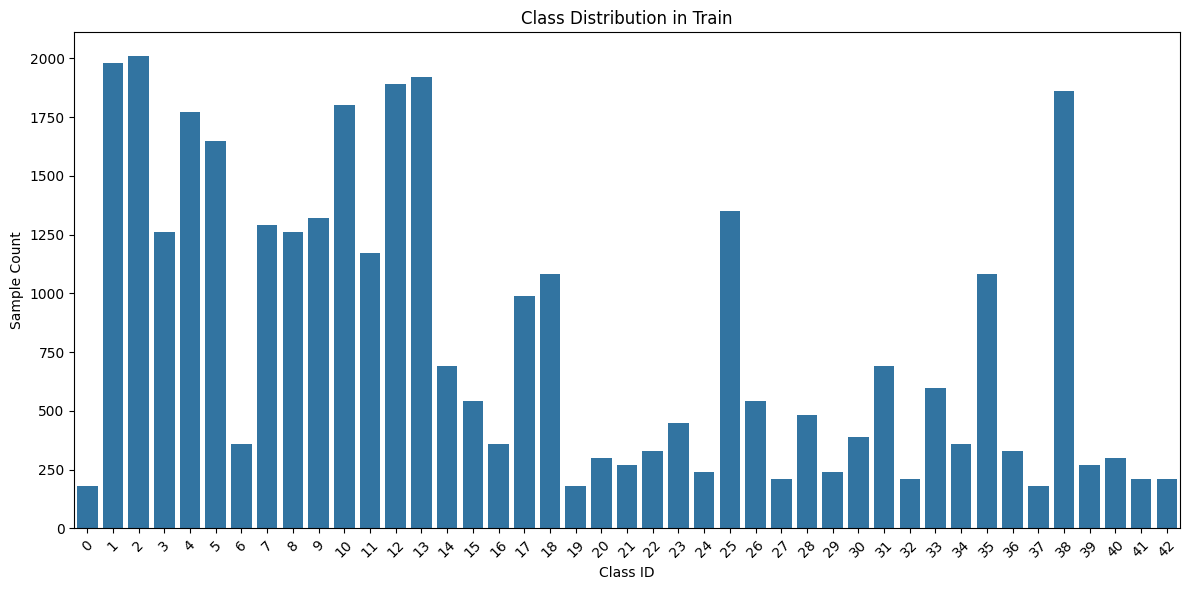

Top 5 most frequent:     count
2    2010
1    1980
13   1920
12   1890
38   1860
Top 5 rarest:     count
0     180
19    180
37    180
27    210
32    210


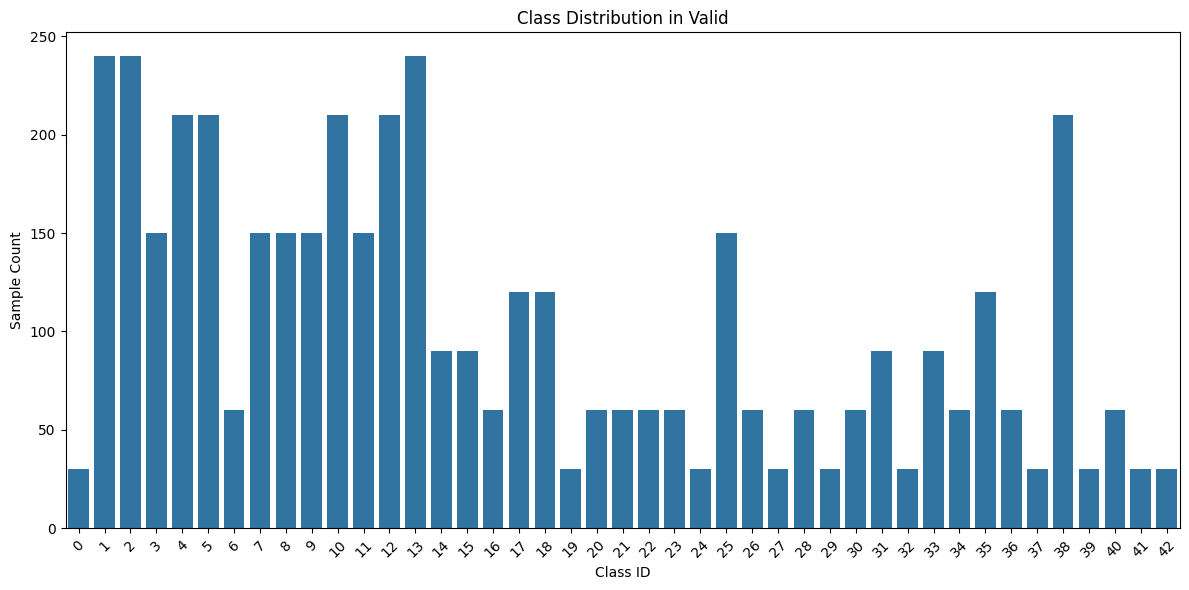

Top 5 most frequent:     count
1     240
2     240
13    240
4     210
5     210
Top 5 rarest:     count
0      30
19     30
24     30
27     30
29     30


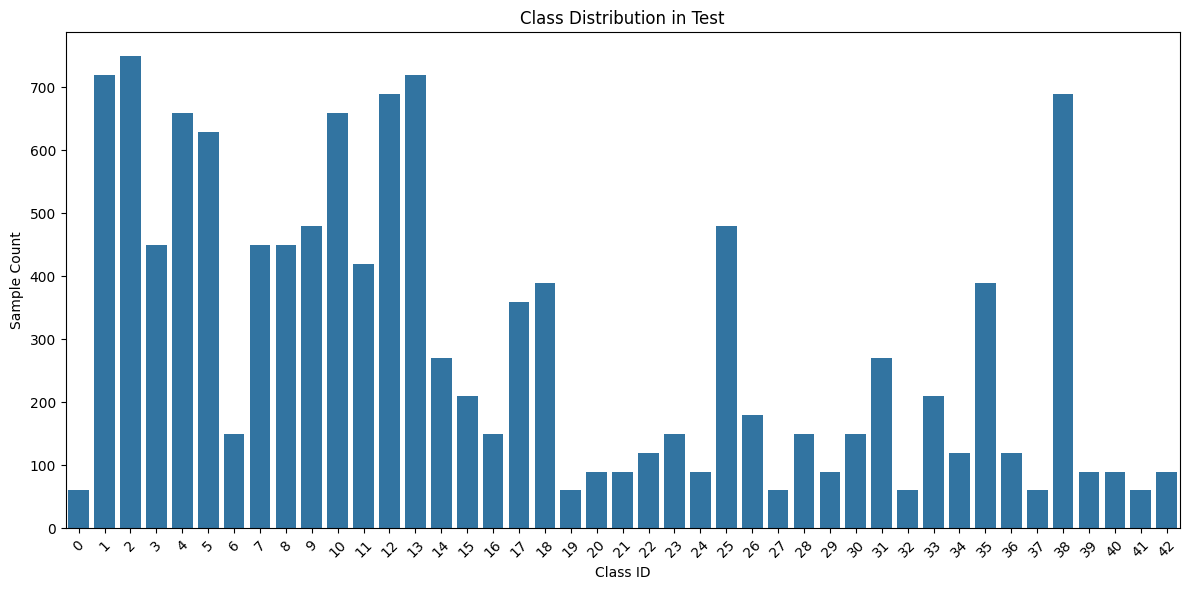

Top 5 most frequent:     count
2     750
1     720
13    720
12    690
38    690
Top 5 rarest:     count
0      60
19     60
27     60
32     60
37     60


In [9]:
class_distribution(train, 'Train')
class_distribution(valid, 'Valid')
class_distribution(test, 'Test')

The class distribution is highly imbalanced, with certain classes containing a very small number of images.

**Rarest Classes:**

* **0** — Speed limit (20 km/h)
* **19** — Dangerous curve to the left
* **27** — Pedestrians
* **37** — Go straight or left
* **32** — End of all speed and passing limits

In [ ]:
sign_classes, class_indices, class_counts = np.unique(y_train, return_index = True, return_counts = True)

for c, c_index, c_count in zip(sign_classes, class_indices, class_counts):
    print("sign classes", c)
    fig = plt.figure(figsize = (10, 2))
    random_indices = random.sample(range(c_index, c_index + c_count), 10)
    for i in range(10):
        axis = fig.add_subplot(1, 10, i + 1, xticks=[], yticks=[])
        axis.imshow(X_train[random_indices[i]])
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

**Class Consistency:** The classes do not contain any incorrect images; all samples correctly match their corresponding traffic sign labels.  
**Image Quality Issues:** There is a noticeable problem with lighting and clarity across the dataset—several images suffer from severe underexposure (too dark), overexposure (too bright), or motion blur.

In [10]:
check_issues(train, 'Train')
check_issues(valid, 'Valid')
check_issues(test, 'Test')


 CHECKING ISSUES FOR TRAIN 
Duplicates in sample 1000: 0
Blank images: 0
Brightness: min=6.64, max=247.65, std=47.18

 CHECKING ISSUES FOR VALID 
Duplicates in sample 1000: 0
Blank images: 0
Brightness: min=10.05, max=233.11, std=49.78

 CHECKING ISSUES FOR TEST 
Duplicates in sample 1000: 0
Blank images: 0
Brightness: min=9.40, max=238.70, std=46.64


* There are exactly 0 blank (all-black) images across all splits. Every sample contains actual pixel data.

* The initial check on a 1,000-sample window shows 0 duplicates, indicating that identical back-to-back frames from the same traffic sign track have been properly filtered out or sampled during dataset creation.

* The pixel brightness ranges from extremely low values (6.6) up to near-maximum intensity (247.6).
A standard deviation (`std`) of ~46 to 49 across all splits is exceptionally high. This confirms that the dataset contains heavily contrasting environments—ranging from deep shadows/night-like frames to harsh daylight glare.



> **Preprocessing:** The technical consistency of these metrics across Train, Valid, and Test sets confirms that the splits are fair. However, the extreme brightness distribution directly justifies the need for global histogram equalization techniques (like **CLAHE**) to normalize contrast before training.

In [11]:
overexposed_idx = []
underexposed_idx = []
blurry_idx = []

for i, img in enumerate(X_train):
    if is_overexposed(img):
        overexposed_idx.append(i)
    if is_underexposed(img):
        underexposed_idx.append(i)
    if is_blurry(img):
        blurry_idx.append(i)

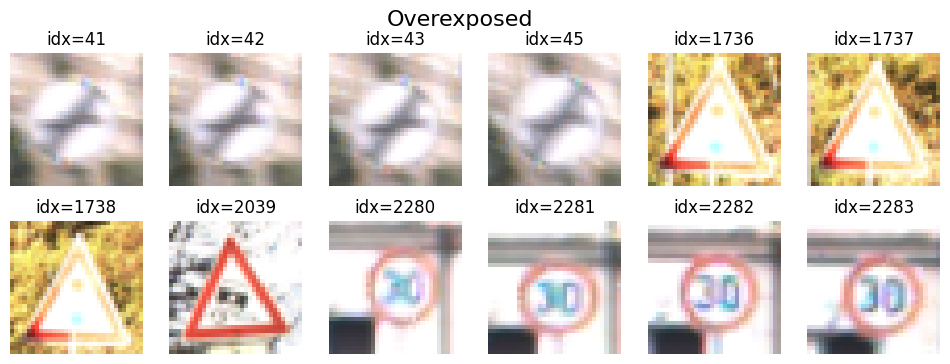

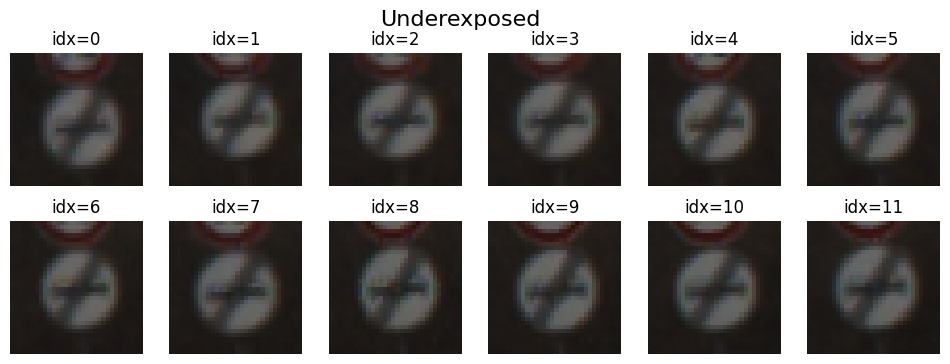

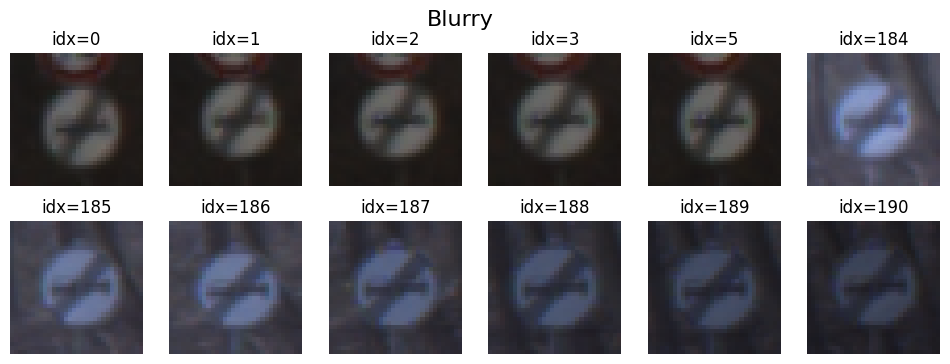

Overexposed: 894
Underexposed: 10459
Blurry: 5932


In [13]:
show_images(X_train, overexposed_idx, "Overexposed")
show_images(X_train, underexposed_idx, "Underexposed")
show_images(X_train, blurry_idx, "Blurry")
print("Overexposed:", len(overexposed_idx))
print("Underexposed:", len(underexposed_idx))
print("Blurry:", len(blurry_idx))


**Overexposed:** **894 images** * These samples have an average grayscale intensity above our threshold (>190). Visually, they suffer from heavy washing out, making sign borders and thin text difficult to distinguish against bright backgrounds.
**Underexposed:** **10,459 images**
These frames are heavily shadowed or shot in low-light conditions, compressing the feature details into a very narrow, dark pixel range.  
**Blurry :** **5,932 images**
Flagged using a low Laplacian variance threshold (<150), these images suffer from motion blur or low structural resolution, softening the edges of the traffic sign icons.

NOTE:
The fact that **over 10,000 images are heavily underexposed** and nearly **6,000 are blurry** strongly emphasizes that a standard global scaling (like just dividing by 255) won't be enough.

To help our Convolutional Neural Network (CNN) learn effectively without getting confused by environmental noise, our upcoming preprocessing step **must** include:

1. Adaptive Contrast Normalization (CLAHE) to restore hidden details in the dark (underexposed) and bright (overexposed) images.
2. Targeted Denoising/Sharpening to stabilize edge detection on the blurry samples.

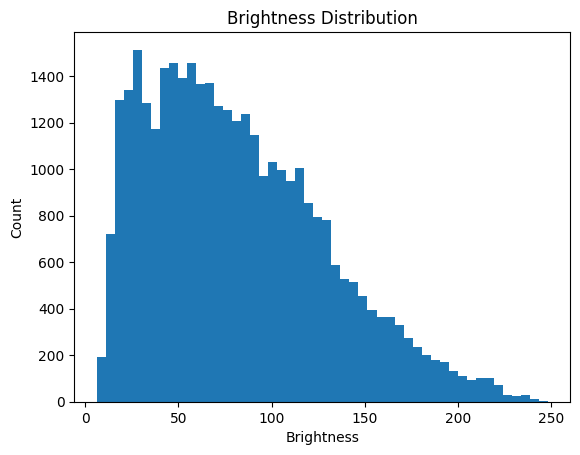

In [14]:
brightness = [np.mean(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)) for img in X_train]

plt.hist(brightness, bins=50)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Count")
plt.show()

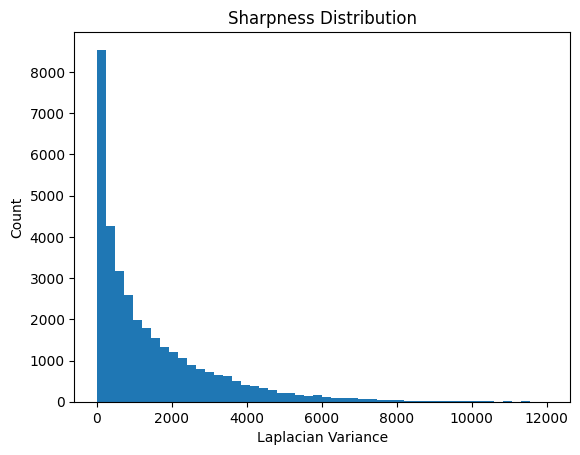

In [15]:
sharpness = [cv2.Laplacian(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cv2.CV_64F).var()
             for img in X_train]

plt.hist(sharpness, bins=50)
plt.title("Sharpness Distribution")
plt.xlabel("Laplacian Variance")
plt.ylabel("Count")
plt.show()

Brightness Distribution:
- The histogram is heavily skewed to the left, with a massive peak concentrated below a value of 50.
- This proves that low-light conditions and deep shadows dominate the dataset. The long right tail represents the few washed-out, overexposed day-time scenes.


Sharpness Distribution:
- The variance drops exponentially and is highly concentrated near zero.
- In computer vision, a low Laplacian variance explicitly means a lack of high-frequency components (sharp edges). This statistical distribution proves that a vast number of images are structurally blurry, soft, or downscaled.

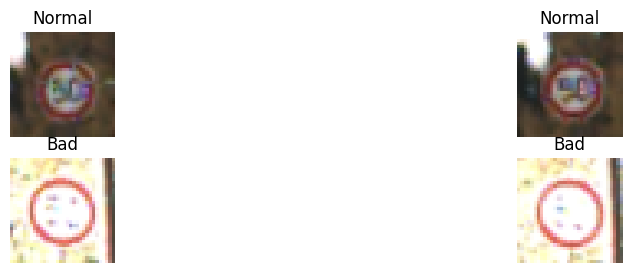

In [16]:
compare_same_class(class_label=2, X=X_train, y=y_train, idx_bad_list=overexposed_idx, n=2)

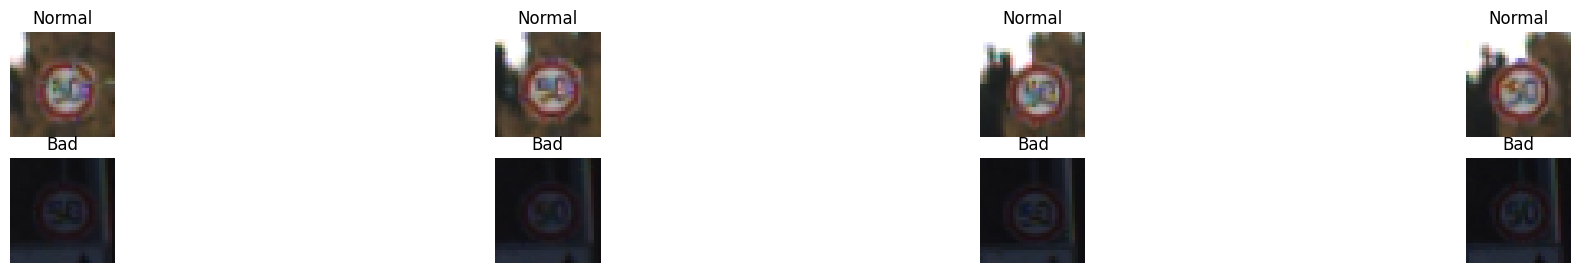

In [17]:
compare_same_class(class_label=2, X=X_train, y=y_train, idx_bad_list=underexposed_idx, n=4)

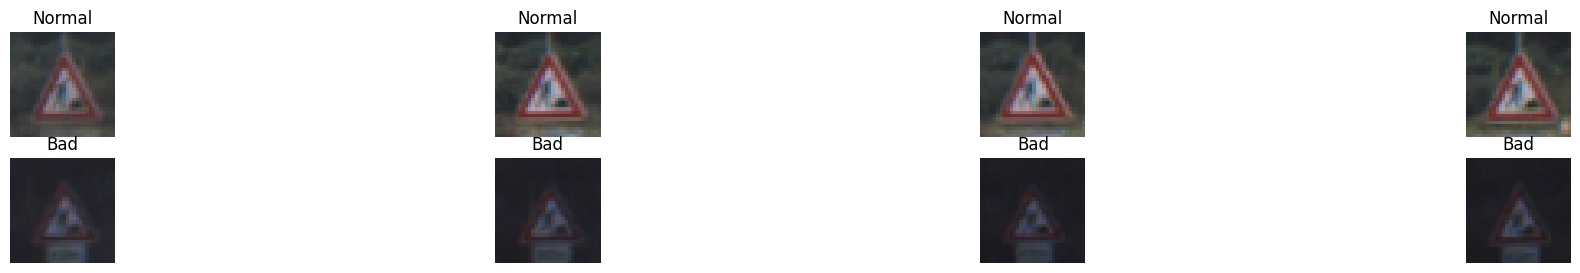

In [18]:
compare_same_class(class_label=25, X=X_train, y=y_train, idx_bad_list=blurry_idx, n=4)

## Data Analysis Summary

* All dataset images are confirmed to be three-channel (RGB).
* There are no corrupt or blank (all-black) images; every sample contains valid pixel data.
* Visual inspection confirms high label consistency — all images correctly belong to their designated traffic sign classes without anomalies.
* The dataset suffers from severe lighting issues, with a massive number of heavily underexposed (dark) and overexposed (washed out) images.

Action:
1. Implement contrast and brightness normalization (using CLAHE and median blur) to rectify environmental noise.
2. Build and evaluate a standard LeNet model on the raw data to establish a benchmark performance.
3. Train the same architecture on the enhanced images to quantify the accuracy improvement driven by our preprocessing pipeline.

# Step 4. Image Preprocessing & Model Architecture

In [19]:
X_train, y_train = shuffle(X_train, y_train,random_state=0)

Data Shuffling for Uniform Distribution
Since the original dataset images are sorted sequentially by tracks and classes, we must shuffle them before training. Shuffling ensures that the training mini-batches are independent and identically distributed (I.I.D.), preventing the model from learning artificial ordering patterns. We include a fixed `random_state` to ensure experiment reproducibility.

## Basis model

In [20]:
basis_model = Sequential()
basis_model.add(Input(shape=X_train[0].shape))
basis_model.add(Conv2D(filters=12, kernel_size=5, activation='relu'))
basis_model.add(MaxPooling2D((2, 2)))

basis_model.add(Conv2D(filters=24, kernel_size=5, activation='relu'))
basis_model.add(MaxPooling2D((2, 2)))

basis_model.add(Flatten())
basis_model.add(Dense(units=86, activation='relu'))
basis_model.add(Dense(units=43, activation='softmax'))


basis_model.compile(optimizer=Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
basis_model.fit(X_train,y_train, epochs=20, verbose=1, validation_data=(X_validation, y_validation))

Epoch 1/20
 191/1088 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.0824 - loss: 16.1343

KeyboardInterrupt: 

In [ ]:
basis_model.save("1Traffic_basismodel.keras")

In [ ]:
evaluate_multiclass_model(basis_model, X_train, y_train, X_test, y_test)

{'train_accuracy': 0.9894249834765367,
 'test_accuracy': 0.911243072050673,
 'train_f1_macro': 0.9872616492653322,
 'test_f1_macro': 0.8655482793854381,
 'train_recall_macro': 0.9881954241063271,
 'test_recall_macro': 0.8669575874168897,
 'train_precision_macro': 0.9867018252971178,
 'test_precision_macro': 0.8805743129094756}

In [ ]:
y_train_proba = basis_model.predict(X_train, verbose=0)
y_test_proba = basis_model.predict(X_test, verbose=0)

y_train_pred = np.argmax(y_train_proba, axis=1)
y_test_pred = np.argmax(y_test_proba, axis=1)

In [ ]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       180
           1       0.99      0.99      0.99      1980
           2       0.98      0.97      0.98      2010
           3       0.95      1.00      0.98      1260
           4       1.00      1.00      1.00      1770
           5       0.98      0.95      0.97      1650
           6       0.99      1.00      1.00       360
           7       0.99      0.98      0.99      1290
           8       0.99      0.98      0.99      1260
           9       0.99      1.00      1.00      1320
          10       0.99      1.00      0.99      1800
          11       0.99      1.00      0.99      1170
          12       1.00      0.99      0.99      1890
          13       0.99      1.00      1.00      1920
          14       1.00      1.00      1.00       690
          15       0.99      0.99      0.99       540
          16       1.00      0.99      0.99       360
          17       1.00    

In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89        60
           1       0.94      0.96      0.95       720
           2       0.97      0.95      0.96       750
           3       0.83      0.94      0.89       450
           4       0.95      0.96      0.96       660
           5       0.91      0.90      0.91       630
           6       0.92      0.83      0.87       150
           7       0.93      0.82      0.87       450
           8       0.90      0.91      0.91       450
           9       0.94      0.93      0.94       480
          10       0.96      0.98      0.97       660
          11       0.84      0.93      0.88       420
          12       0.98      0.92      0.95       690
          13       0.98      0.98      0.98       720
          14       0.97      0.89      0.93       270
          15       0.91      0.90      0.91       210
          16       1.00      0.99      0.99       150
          17       0.99    


* The baseline model reaches an impressive *98.9% accuracy on the training set*, but drops to *91.1% on the test set*. This ~8% performance gap indicates clear overfitting to environmental conditions present only in the training split.
* While the global accuracy is 91.1%, the Macro F1-Score on the test set drops significantly to 86.5%. Looking closely at the classification report, the model completely fails or predicts weakly on rare classes (like Class 27 — Pedestrians with a $56\%$ F1-score, or Class 41 with $58\%$).

* Since the raw images contain extreme contrast gaps (underexposure) and motion blur, the network's convolutional kernels are wasting parameters memorizing background noise and lighting variations rather than learning invariant geometric features of the signs.

## LeNet


Standard LeNet-5 Architecture
| Layer | ype            | Output Size | Note                              |
| ---- | --------------- | ------------- | --------------------------------------- |
| 1    | Convolution     | 6×28×28       | 6 filters 5×5, stride=1, padding=valid |
| 2    | Pooling         | 6×14×14       | Average Pooling 2×2, stride=2           |
| 3    | Convolution     | 16×10×10      | 16 filters 5×5, stride=1               |
| 4    | Pooling         | 16×5×5        | Average Pooling 2×2, stride=2           |
| 5    | Flatten         | 400           | —                                       |
| 6    | Fully Connected | 120           | —                                       |
| 7    | Fully Connected | 84            | —                                       |
| 8    | Fully Connected | 10            | Softmax for classification               |


Activation Functions: In the original LeNet, $\tanh$ was used (modern implementations typically use **ReLU**).

The original architecture utilized *Average Pooling*, but modern frameworks commonly substitute it with **Max Pooling** for better feature retention.

In [26]:
X_trainL = X_train.astype('float32') / 255.
X_validationL = X_validation.astype('float32') / 255.
X_testL = X_test.astype('float32') / 255.

To prevent exploding gradients and ensure numerical stability during the forward pass, we cast our raw pixel arrays to float32 and scale them linearly into a strict $[0.0, 1.0]$

In [ ]:
LeNet_model = Sequential()
LeNet_model.add(Input(shape=X_train[0].shape))
LeNet_model.add(Conv2D(filters=6, kernel_size=5, activation='relu'))
LeNet_model.add(MaxPooling2D((2, 2)))

LeNet_model.add(Conv2D(filters=16, kernel_size=5, activation='relu'))
LeNet_model.add(MaxPooling2D((2, 2)))

LeNet_model.add(Flatten())
LeNet_model.add(Dense(units=172, activation='relu'))
LeNet_model.add(Dense(units=86, activation='relu'))
LeNet_model.add(Dense(units=43, activation='softmax'))

LeNet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 172)            │        68,972 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 86)             │        14,878 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 43)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,463 (353.37 KB)

 Trainable params: 90,463 (353.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
LeNet_model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

In [ ]:
LeNet_model.fit(X_trainL, y_train, epochs=30,verbose=1, validation_data=(X_validationL, y_validation))

Epoch 1/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3725 - loss: 2.4304 - val_accuracy: 0.7460 - val_loss: 0.9233
Epoch 2/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8581 - loss: 0.5155 - val_accuracy: 0.8274 - val_loss: 0.6310
Epoch 3/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9330 - loss: 0.2580 - val_accuracy: 0.8483 - val_loss: 0.5604
Epoch 4/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9557 - loss: 0.1750 - val_accuracy: 0.8633 - val_loss: 0.5532
Epoch 5/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9686 - loss: 0.1303 - val_accuracy: 0.8744 - val_loss: 0.5438
Epoch 6/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9747 - loss: 0.1034 - val_accuracy: 0.8803 - val_loss: 0.5081
Epoch 7/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9784 - loss: 0.0831 - val_accuracy: 0.8975 - val_loss: 0.4489
Epoch 8/30
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9849 - loss: 0.0588 

In [ ]:
evaluate_multiclass_model(LeNet_model, X_trainL, y_train, X_testL, y_test)

{'train_accuracy': 0.997787292738297,
 'test_accuracy': 0.9155977830562153,
 'train_f1_macro': 0.9974876587390725,
 'test_f1_macro': 0.8778745850630986,
 'train_recall_macro': 0.9980497308111969,
 'test_recall_macro': 0.8879446020313057,
 'train_precision_macro': 0.9969566730173954,
 'test_precision_macro': 0.8789786441409362}

We conducted a comparative analysis between the original LeNet-5 architecture and a modernized implementation. The results are as follows:

**Impact of Activation Functions**<br>
| Activation  | test_accuracy | test_f1_macro |
| -------- | ------------- | ------------- |
| **Tanh** | 0.86          | 0.80          |
| **ReLU** | 0.90          | 0.86          |


**Impact of Pooling Strategy**<br>
| Pooling Type       | test_accuracy | test_f1_macro |
| ------------------ | ------------- | ------------- |
| **AveragePooling** | 0.90          | 0.86          |
| **MaxPooling**     | 0.92          | 0.88          |

train_accuracy: 1.0  
test_accuracy: 0.92  
There is a noticeable degree of overfitting (indicated by the 100% training accuracy vs. 92% test accuracy). To mitigate this and further improve model generalization, we will now proceed with image preprocessing.

Key Findings:

* **ReLU** outperformed $\tanh$ due to faster convergence and the mitigation of the vanishing gradient problem.
* **MaxPooling** proved superior to Average Pooling, as it effectively preserves the most critical spatial features, such as sharp sign borders and contours.

Overfitting Analysis: The ~8% performance gap between training and testing accuracy, combined with the significant environmental noise identified in the data, indicates that the model isoverfitting to noise (glare, shadows, motion blur) rather than learning invariant geometric features of the traffic signs.

In [ ]:
LeNet_model.save("1Traffic_LeNetmodel.keras")

## LeNet with Preprocessing
Image Enhancement: Brightness and contrast adjustment (using CLAHE).

Data Augmentation: Expanding the dataset to improve generalization.

Normalization: Scaling pixel values for numerical stability.

Standardization: Adjusting data distribution (mean and variance).

In [7]:
X_train_pp = X_train.copy()
X_validation_pp = X_validation.copy()
X_test_pp = X_test.copy()

# Initialize CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply Image Enhancement
X_train_pp = np.array([enhance(i) for i in X_train_pp])
X_validation_pp = np.array([enhance(i) for i in X_validation_pp])
X_test_pp = np.array([enhance(i) for i in X_test_pp])

# Apply Denoising to reduce high-frequency artifacts
X_train_pp = np.array([denoise(i) for i in X_train_pp])
X_validation_pp = np.array([denoise(i) for i in X_validation_pp])
X_test_pp = np.array([denoise(i) for i in X_test_pp])

# Standardization
mean = np.mean(X_train_pp, axis=(0, 1, 2), keepdims=True)
std = np.std(X_train_pp, axis=(0, 1, 2), keepdims=True) + 1e-7

# Shift distribution to mean=0 and scale to std=1
X_train_pp = (X_train_pp - mean) / std
X_validation_pp = (X_validation_pp - mean) / std
X_test_pp = (X_test_pp - mean) / std

In [8]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=10
)

datagen.fit(X_train_pp)

In [9]:
LeNet_model_pp = Sequential()
LeNet_model_pp.add(Input(shape=X_train_pp[0].shape))
LeNet_model_pp.add(Conv2D(filters=6, kernel_size=5, activation='relu'))
LeNet_model_pp.add(BatchNormalization())
LeNet_model_pp.add(MaxPooling2D((2, 2)))

LeNet_model_pp.add(Conv2D(filters=16, kernel_size=5, activation='relu'))
LeNet_model_pp.add(BatchNormalization())
LeNet_model_pp.add(MaxPooling2D((2, 2)))

LeNet_model_pp.add(Flatten())
LeNet_model_pp.add(Dense(units=172, activation='relu'))
LeNet_model_pp.add(BatchNormalization())
LeNet_model_pp.add(Dense(units=86, activation='relu'))
LeNet_model_pp.add(BatchNormalization())
LeNet_model_pp.add(Dense(units=43, activation='softmax'))

In [10]:
LeNet_model_pp.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0005), metrics=['accuracy'])

In [11]:
history = LeNet_model_pp.fit(datagen.flow(X_train_pp, y_train, batch_size=64), epochs=30, verbose=1, validation_data=(X_validation_pp, y_validation))

Epoch 1/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 36s 53ms/step - accuracy: 0.5019 - loss: 1.8609 - val_accuracy: 0.7277 - val_loss: 0.8533
Epoch 2/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.7577 - loss: 0.8145 - val_accuracy: 0.8324 - val_loss: 0.4985
Epoch 3/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.8348 - loss: 0.5438 - val_accuracy: 0.8694 - val_loss: 0.3953
Epoch 4/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8766 - loss: 0.4068 - val_accuracy: 0.8848 - val_loss: 0.3450
Epoch 5/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.8987 - loss: 0.3277 - val_accuracy: 0.8896 - val_loss: 0.3451
Epoch 6/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.9118 - loss: 0.2782 - val_accuracy: 0.9132 - val_loss: 0.2824
Epoch 7/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.9216 - loss: 0.2428 - val_accuracy: 0.9109 - val_loss: 0.2873
Epoch 8/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.9299 - loss: 0.2159 - 

In [18]:
evaluate_multiclass_model(LeNet_model_pp, X_train_pp, y_train, X_test_pp, y_test)

{'train_accuracy': 0.9914652719905744,
 'test_accuracy': 0.9356294536817102,
 'train_f1_macro': 0.9925211016764105,
 'test_f1_macro': 0.9067764408867526,
 'train_recall_macro': 0.992756078663229,
 'test_recall_macro': 0.9039815056961165,
 'train_precision_macro': 0.9924882607582193,
 'test_precision_macro': 0.916174229997146}

In [19]:
y_test_proba = LeNet_model_pp.predict(X_test_pp, verbose=0)

y_test_pred = np.argmax(y_test_proba, axis=1)
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.93      0.88        60
           1       0.96      0.93      0.94       720
           2       0.83      0.98      0.90       750
           3       0.93      0.89      0.91       450
           4       0.96      0.97      0.96       660
           5       0.90      0.80      0.84       630
           6       0.96      0.85      0.90       150
           7       0.97      0.86      0.91       450
           8       0.88      0.97      0.92       450
           9       0.97      1.00      0.98       480
          10       0.97      0.99      0.98       660
          11       0.88      0.95      0.92       420
          12       1.00      0.96      0.98       690
          13       0.99      1.00      0.99       720
          14       0.98      1.00      0.99       270
          15       0.97      0.89      0.93       210
          16       0.99      0.97      0.98       150
          17       1.00    

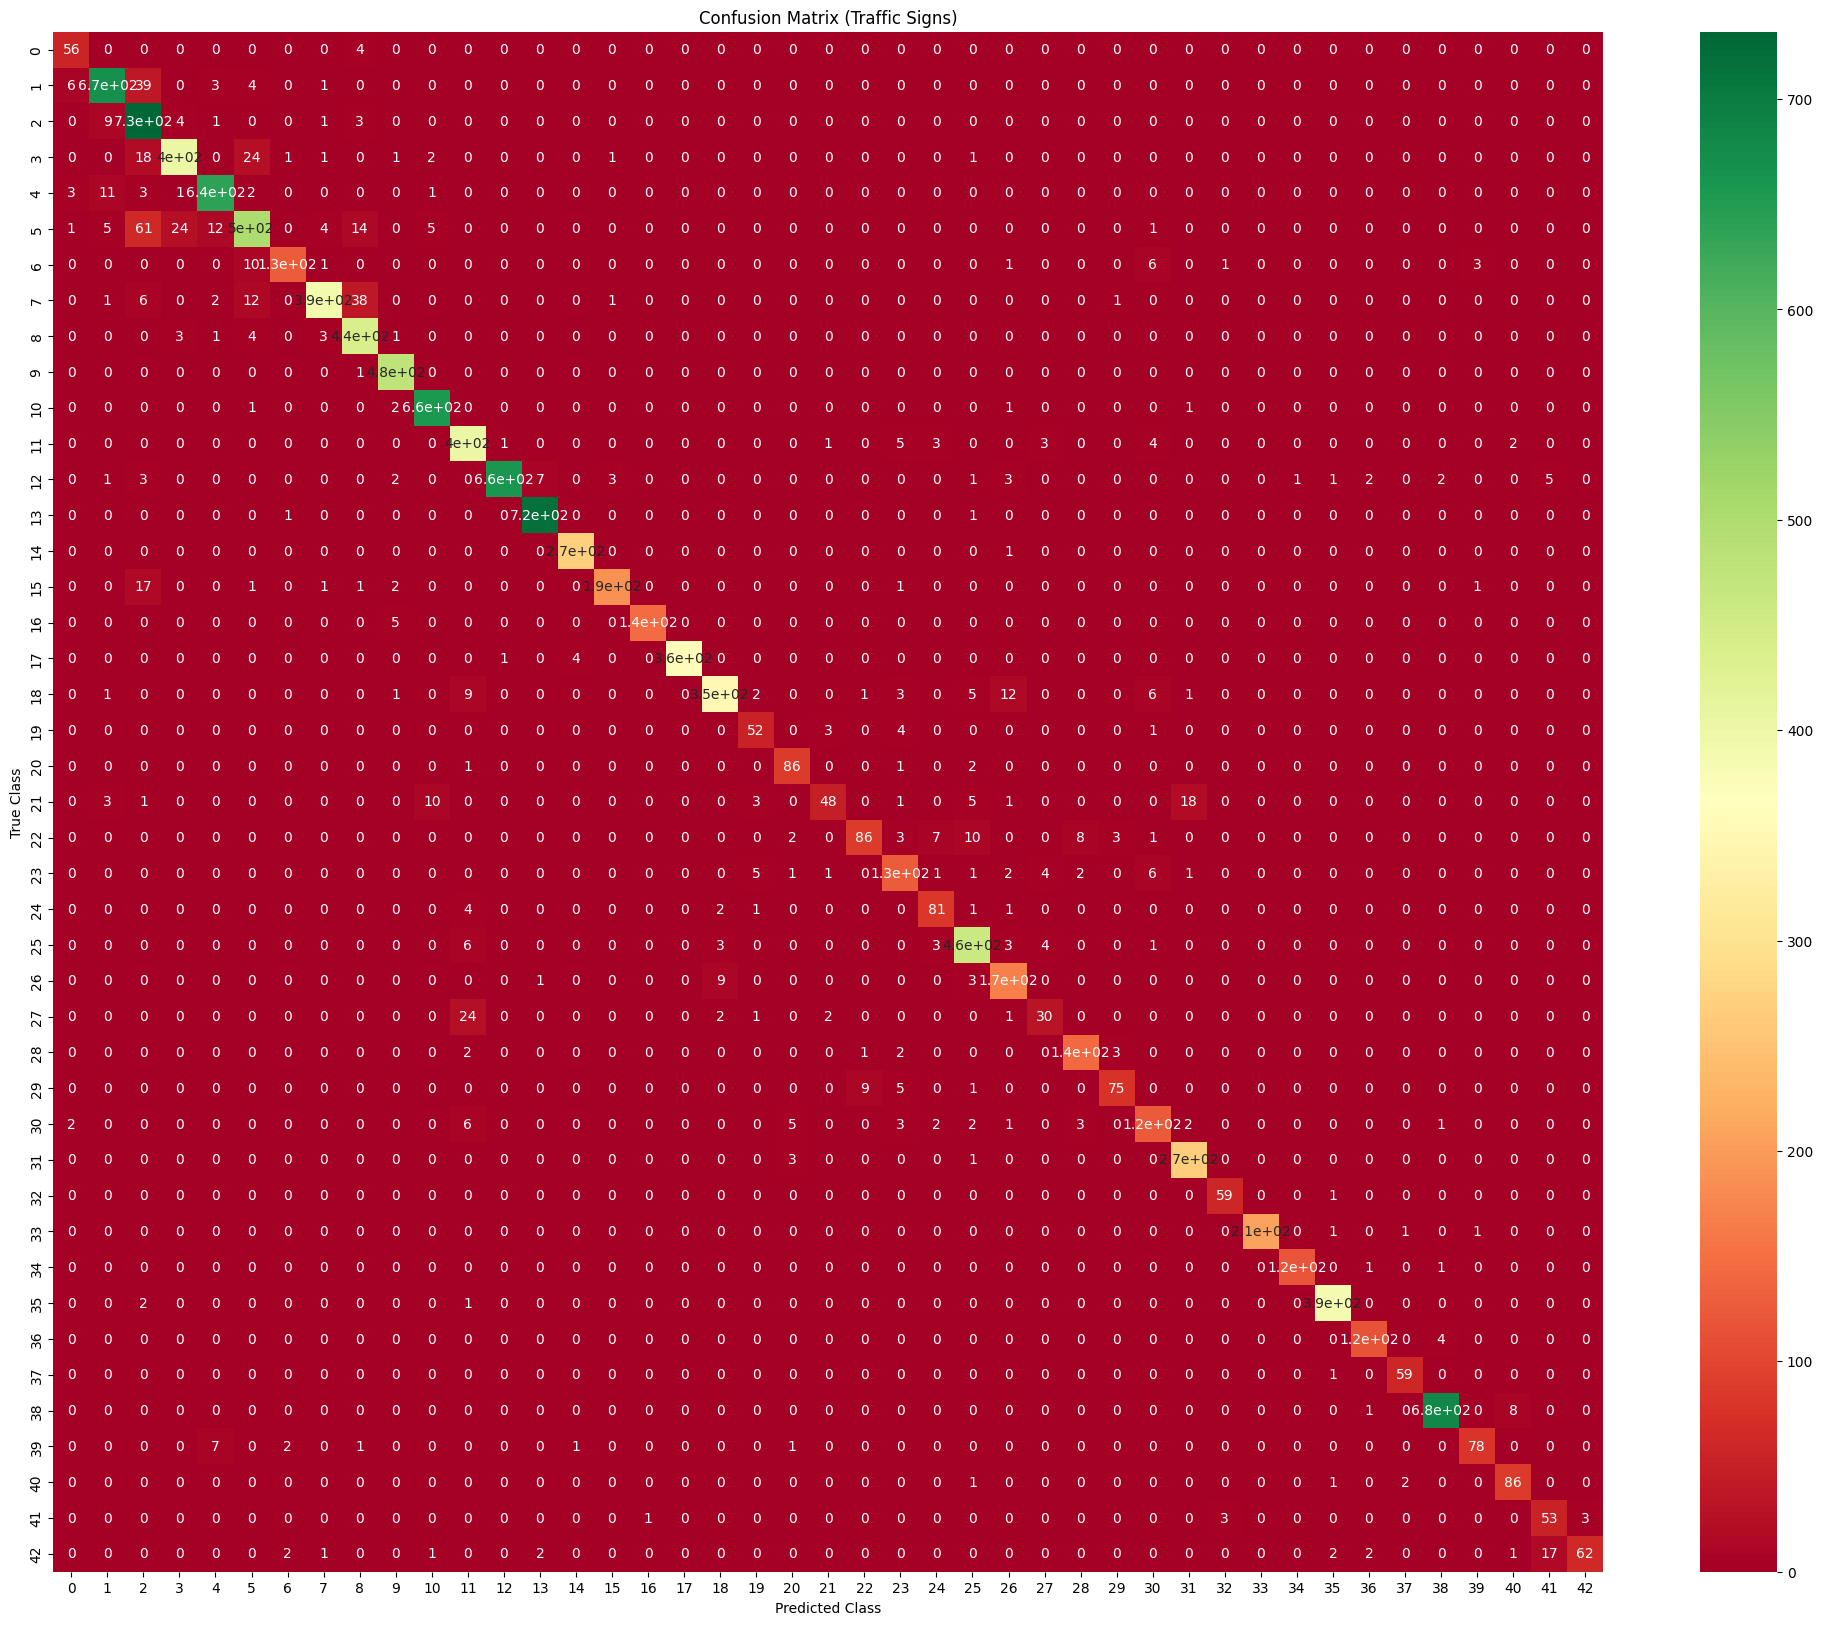

In [50]:
cm = confusion_matrix(y_test, y_test_pred)
mask = np.eye(cm.shape[0], dtype=bool)
plt.figure(figsize=(25,20))
sns.heatmap(cm,cmap="RdYlGn", annot=True)
plt.title('Confusion Matrix (Traffic Signs)')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

In [22]:
LeNet_model_pp.save("1Traffic_LeNetmodelPP.keras")

Performance improvement achieved through enhanced preprocessing. The dataset is quite challenging due to significantly distorted and dark images. While the current results are promising, we aim to further optimize the model using a custom architecture and training callbacks (EarlyStopping, ModelCheckpoint). Our primary goal is to maximize generalization and eliminate overfitting

In [23]:
X_train_custom = X_train.copy()
X_validation_custom = X_validation.copy()
X_test_custom = X_test.copy()

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

X_train_custom = np.array([denoise(enhance(i)) for i in X_train_custom], dtype=np.float32)
X_validation_custom = np.array([denoise(enhance(i)) for i in X_validation_custom], dtype=np.float32)
X_test_custom = np.array([denoise(enhance(i)) for i in X_test_custom], dtype=np.float32)

mean = np.mean(X_train_custom, axis=(0, 1, 2), keepdims=True)
std = np.std(X_train_custom, axis=(0, 1, 2), keepdims=True) + 1e-7

X_train_custom = (X_train_custom - mean) / std
X_validation_custom = (X_validation_custom - mean) / std
X_test_custom = (X_test_custom - mean) / std

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=10
)

datagen.fit(X_train_custom)

In [ ]:
Cus_model = Sequential()
Cus_model.add(Input(shape=X_train_custom[0].shape))

Cus_model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
Cus_model.add(BatchNormalization())
Cus_model.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
Cus_model.add(BatchNormalization())
Cus_model.add(MaxPooling2D(pool_size=(2, 2)))
Cus_model.add(Dropout(0.25))


Cus_model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
Cus_model.add(BatchNormalization())
Cus_model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
Cus_model.add(BatchNormalization())
Cus_model.add(MaxPooling2D(pool_size=(2, 2)))
Cus_model.add(Dropout(0.35))


Cus_model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
Cus_model.add(BatchNormalization())
Cus_model.add(MaxPooling2D(pool_size=(2, 2)))
Cus_model.add(Dropout(0.4))

Cus_model.add(Flatten())
Cus_model.add(Dense(units=256, activation='relu'))
Cus_model.add(BatchNormalization())
Cus_model.add(Dropout(0.5))
Cus_model.add(Dense(units=43, activation='softmax'))

Cus_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

Cus_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,323 (2.58 MB)

 Trainable params: 676,171 (2.58 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
es = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

mc = ModelCheckpoint(
    '1Traffic_custom_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
Cus_model.fit(
    datagen.flow(X_train_custom, y_train, batch_size=64),
    steps_per_epoch=len(X_train_custom) // 64,
    epochs=50,
    validation_data=(X_validation_custom, y_validation),
    callbacks=[es, rlr, mc],
    verbose=1)

Epoch 1/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3012 - loss: 2.8494
Epoch 1: val_accuracy improved from -inf to 0.78866, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 45s 59ms/step - accuracy: 0.3015 - loss: 2.8476 - val_accuracy: 0.7887 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 2/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.6875 - loss: 0.9441
Epoch 2: val_accuracy did not improve from 0.78866
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - accuracy: 0.6875 - loss: 0.9441 - val_accuracy: 0.7887 - val_loss: 0.6869 - learning_rate: 0.0010
Epoch 3/50
542/543 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7454 - loss: 0.7996
Epoch 3: val_accuracy improved from 0.78866 to 0.90522, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.7455 - loss: 0.7991 - val_accuracy: 0.9052 - val_loss: 0.3195 - learning_rate: 0.0010
Epoch 4/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8594 - loss: 0.5309
Epoch 4: val_accuracy improved from 0.90522 to 0.90658, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8594 - loss: 0.5309 - val_accuracy: 0.9066 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 5/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8605 - loss: 0.4268
Epoch 5: val_accuracy improved from 0.90658 to 0.93039, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.8606 - loss: 0.4268 - val_accuracy: 0.9304 - val_loss: 0.2118 - learning_rate: 0.0010
Epoch 6/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9062 - loss: 0.2782
Epoch 6: val_accuracy improved from 0.93039 to 0.93061, saving model to best_gtsrb_cnn.h5


...

543/543 ━━━━━━━━━━━━━━━━━━━━ 31s 58ms/step - accuracy: 0.9434 - loss: 0.1727 - val_accuracy: 0.9737 - val_loss: 0.0941 - learning_rate: 0.0010
Epoch 14/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9531 - loss: 0.1523
Epoch 14: val_accuracy did not improve from 0.97370
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9531 - loss: 0.1523 - val_accuracy: 0.9730 - val_loss: 0.0943 - learning_rate: 0.0010
Epoch 15/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9516 - loss: 0.1536
Epoch 15: val_accuracy did not improve from 0.97370
543/543 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9516 - loss: 0.1536 - val_accuracy: 0.9653 - val_loss: 0.1350 - learning_rate: 0.0010
Epoch 16/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.8906 - loss: 0.2153
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: val_accuracy did not improve from 0.97370
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.2153

543/543 ━━━━━━━━━━━━━━━━━━━━ 30s 55ms/step - accuracy: 0.9599 - loss: 0.1202 - val_accuracy: 0.9739 - val_loss: 0.1045 - learning_rate: 5.0000e-04
Epoch 18/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9688 - loss: 0.0580
Epoch 18: val_accuracy improved from 0.97392 to 0.97415, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9688 - loss: 0.0580 - val_accuracy: 0.9741 - val_loss: 0.1041 - learning_rate: 5.0000e-04
Epoch 19/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9702 - loss: 0.0941
Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: val_accuracy did not improve from 0.97415
543/543 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9702 - loss: 0.0941 - val_accuracy: 0.9710 - val_loss: 0.1108 - learning_rate: 5.0000e-04
Epoch 20/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9531 - loss: 0.1175
Epoch 20: val_accuracy did not improve from 0.97415
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step - accuracy: 0.9531 - loss: 0.1175 - val_accuracy: 0.9714 - val_loss: 0.1109 - learning_rate: 2.5000e-04
Epoch 21/50
543/543 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9714 - loss: 0.0865
Epoch 21: val_accuracy improved from 0.97415 to 0.97755, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9715 - loss: 0.0865 - val_accuracy: 0.9776 - val_loss: 0.0823 - learning_rate: 2.5000e-04
Epoch 22/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9688 - loss: 0.0667
Epoch 22: val_accuracy improved from 0.97755 to 0.97778, saving model to best_gtsrb_cnn.h5


543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9688 - loss: 0.0667 - val_accuracy: 0.9778 - val_loss: 0.0812 - learning_rate: 2.5000e-04
Epoch 23/50
542/543 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9747 - loss: 0.0781
Epoch 23: val_accuracy did not improve from 0.97778
543/543 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.9747 - loss: 0.0781 - val_accuracy: 0.9776 - val_loss: 0.0763 - learning_rate: 2.5000e-04
Epoch 24/50
  1/543 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9688 - loss: 0.0786
Epoch 24: val_accuracy did not improve from 0.97778
543/543 ━━━━━━━━━━━━━━━━━━━━ 1s 990us/step - accuracy: 0.9688 - loss: 0.0786 - val_accuracy: 0.9773 - val_loss: 0.0759 - learning_rate: 2.5000e-04
Epoch 25/50
542/543 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9768 - loss: 0.0715
Epoch 25: val_accuracy did not improve from 0.97778
543/543 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.9767 - loss: 0.0715 - val_accuracy: 0.9748 - val_loss: 0.0901 - learning_rate: 2.500

In [ ]:
evaluate_multiclass_model(Cus_model, X_train_custom, y_train, X_test_custom, y_test)

{'train_accuracy': 0.9981033937756832,
 'test_accuracy': 0.9680126682501979,
 'train_f1_macro': 0.9981020554199952,
 'test_f1_macro': 0.9474121881559712,
 'train_recall_macro': 0.9979744195929474,
 'test_recall_macro': 0.9494839390284285,
 'train_precision_macro': 0.9982344629870802,
 'test_precision_macro': 0.9506332078133756}

# Result

In [24]:
basis = load_model("1Traffic_basismodel.keras")
LeNet = load_model("1Traffic_LeNetmodel.keras")
LeNet_pp = load_model("1Traffic_LeNetmodelPP.keras")
Custom = load_model("1Traffic_custom_model.keras")

In [27]:
datasets = {
    "Basis": (X_train, y_train, X_test, y_test),
    "LeNet": (X_trainL, y_train, X_testL, y_test),
    "LeNet_pp": (X_train_pp, y_train, X_test_pp, y_test),
    "Custom": (X_train_custom, y_train, X_test_custom, y_test)
}

In [28]:
models = {
    "Basis": basis,
    "LeNet": LeNet,
    "LeNet_pp": LeNet_pp,
    "Custom": Custom
}

In [29]:
results = {}

for name in models:
    model = models[name]
    X_train_m, y_train_m, X_test_m, y_test_m = datasets[name]

    y_pred_train = np.argmax(model.predict(X_train_m), axis=1)
    y_pred_test = np.argmax(model.predict(X_test_m), axis=1)

    results[name] = {
        "Accuracy_train": accuracy_score(y_train_m, y_pred_train)*100,
        "Accuracy_test": accuracy_score(y_test_m, y_pred_test)*100,
        "Precision_train": precision_score(y_train_m, y_pred_train, average="macro")*100,
        "Precision_test": precision_score(y_test_m, y_pred_test, average="macro")*100,
        "Recall_train": recall_score(y_train_m, y_pred_train, average="macro")*100,
        "Recall_test": recall_score(y_test_m, y_pred_test, average="macro")*100,
        "F1_train": f1_score(y_train_m, y_pred_train, average="macro")*100,
        "F1_test": f1_score(y_test_m, y_pred_test, average="macro")*100}

1088/1088 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1088/1088 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


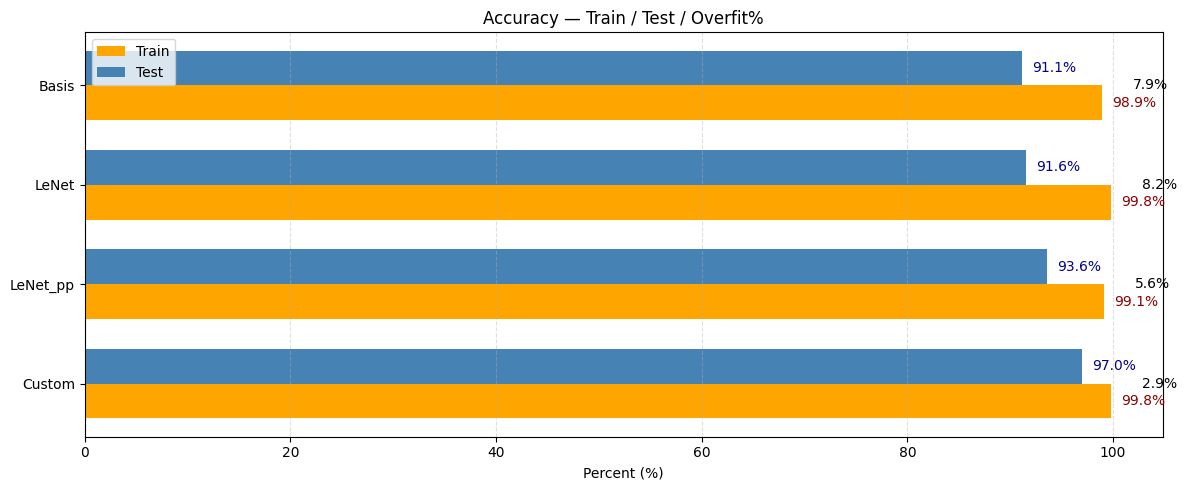

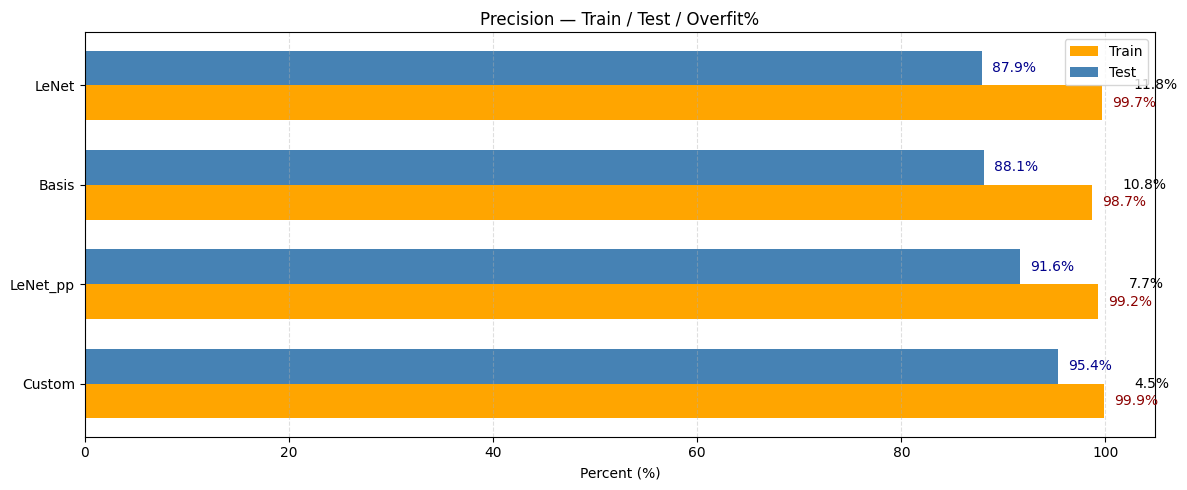

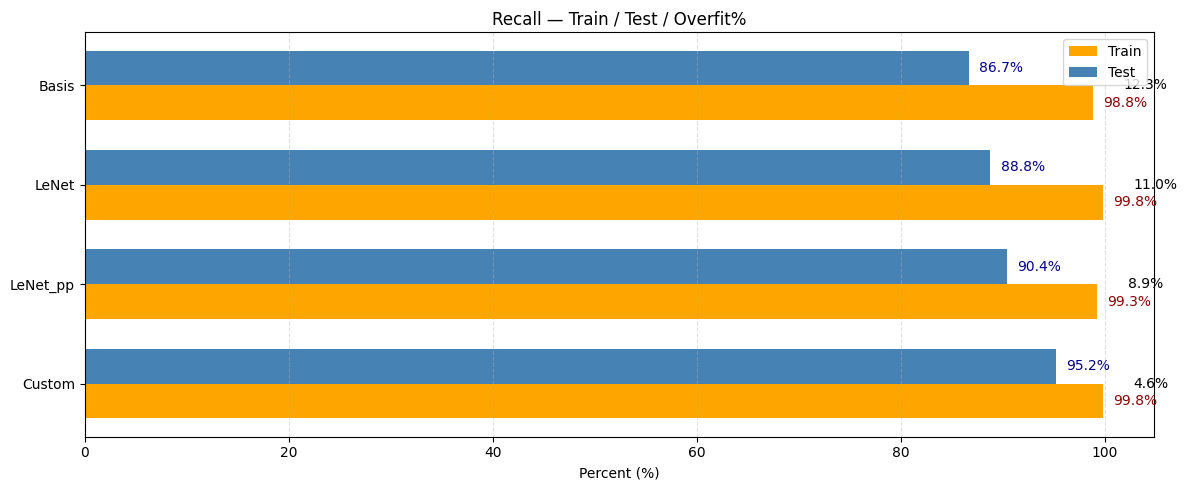

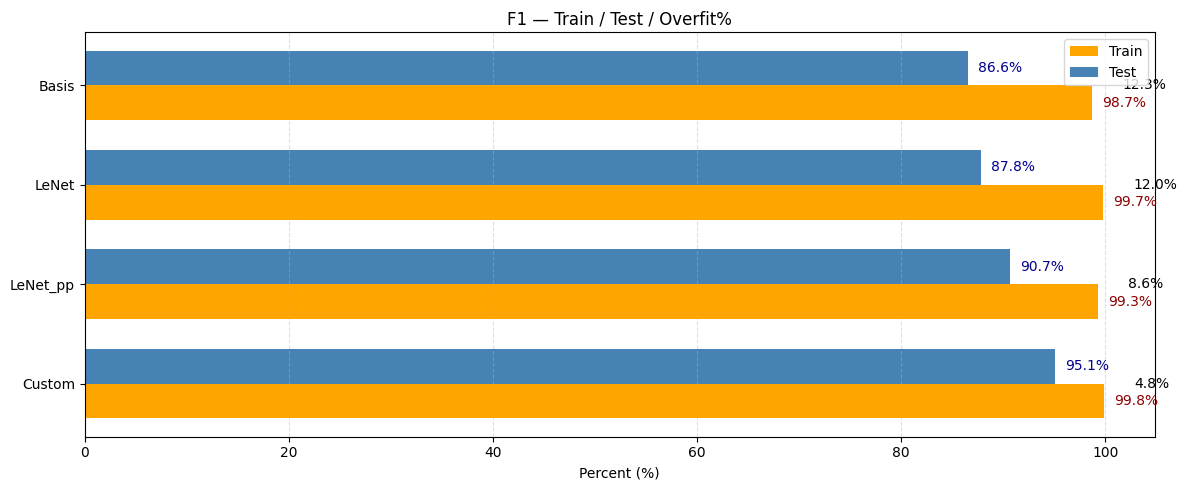

In [30]:
plot_results(results)

395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


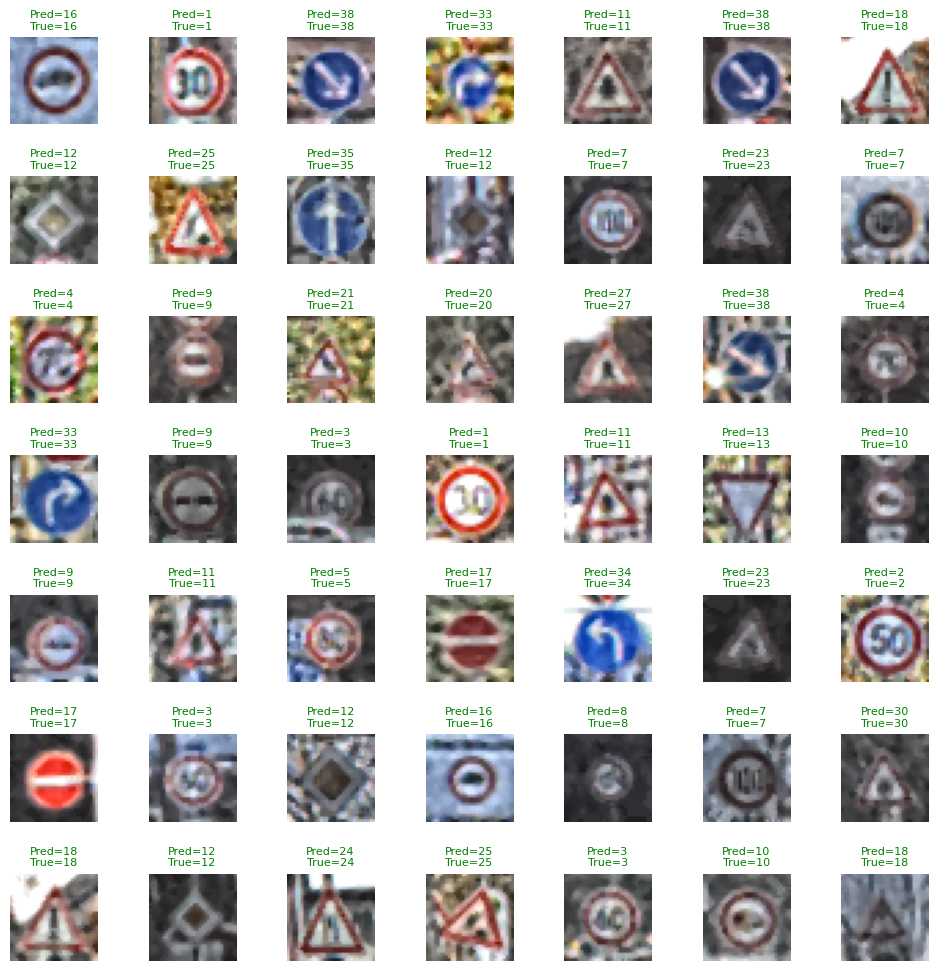

In [36]:
# Custom
y_pred = np.argmax(Custom.predict(X_test_custom), axis=1)
y_true = y_test

L = 7
W = 7

fig, axes = plt.subplots(L, W, figsize=(12, 12))
axes = axes.ravel()

for i in range(L*W):
    img = (X_test_custom[i] * std + mean).squeeze()
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    pred = y_pred[i]
    true = y_true[i]
    color = "green" if pred == true else "red"

    axes[i].set_title(f"Pred={pred}\nTrue={true}", color=color, fontsize=8)
    axes[i].axis("off")

plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


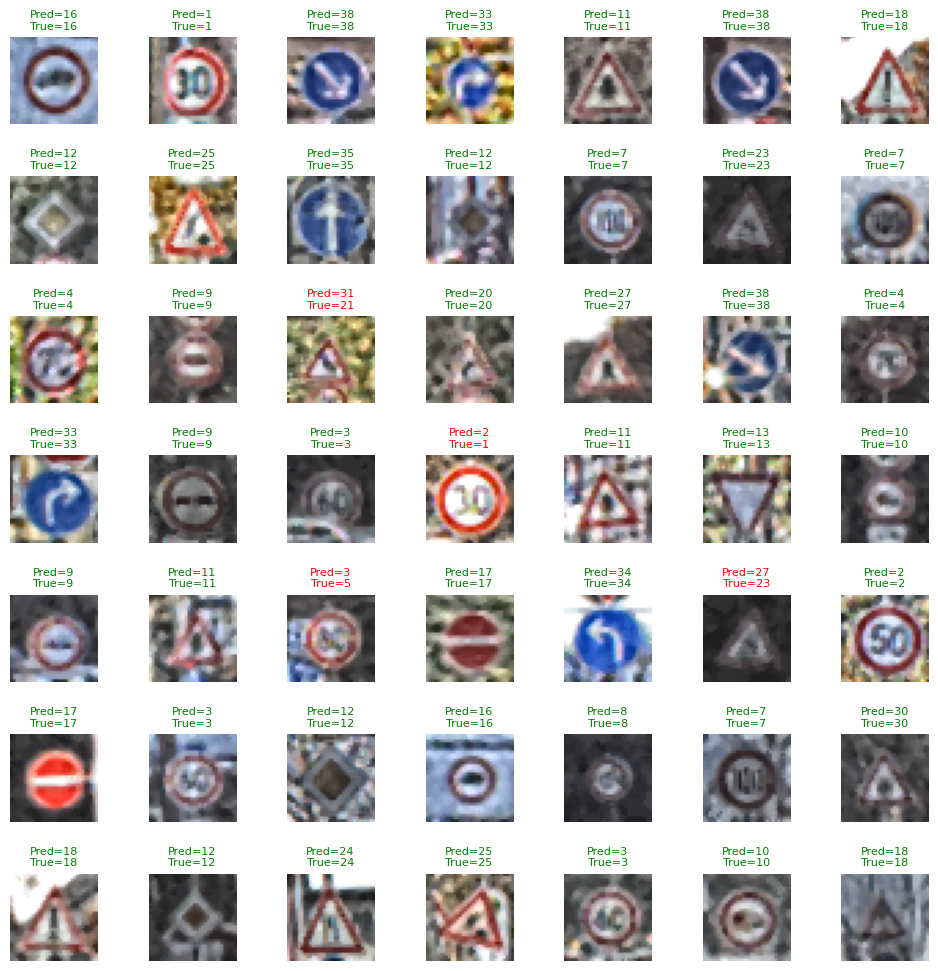

In [35]:
# LeNet preprocessing
y_pred = np.argmax(LeNet_pp.predict(X_test_pp), axis=1)
y_true = y_test

L = 7
W = 7

fig, axes = plt.subplots(L, W, figsize=(12, 12))
axes = axes.ravel()

for i in range(L*W):
    img = (X_test_pp[i] * std + mean).squeeze()
    img = np.clip(img, 0, 1)

    axes[i].imshow(img)

    pred = y_pred[i]
    true = y_true[i]
    color = "green" if pred == true else "red"

    axes[i].set_title(f"Pred={pred}\nTrue={true}", color=color, fontsize=8)
    axes[i].axis("off")

plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()

# Conclusion

This project involved a comprehensive performance evaluation comparing a preprocessing LeNet architecture against a refined Custom CNN.

Model Performance: The Custom CNN achieved near-optimal classification accuracy (>97%), proving to be the superior choice for high-stakes scenarios requiring maximum reliability. However, its deeper architecture results in a longer inference time (predict time), which may be a constraint for real-time edge deployment.

Efficiency: The LeNet model demonstrated significantly faster inference speeds, offering a viable "lightweight" alternative for performance-constrained environments.

Key Finding: The rigorous preprocessing pipeline - specifically the use of CLAHE for contrast normalization and median filtering for noise reduction - proved to be the most critical factor. It effectively neutralized environmental artifacts (lighting variance and motion blur), significantly elevating the accuracy of both models.